# Example-29: Detection of anomalies using frequency data

In [1]:
# In this example the objective is to detect signals with anomalies using frequency data

# To achieving this, shifted samples are generated from each signal
# For each sample frequency is computed
# These frequencies are used as features in anomaly detection

# For anomaly detection, several methods are used
# Threshold based detector is based on (robust) dispersion estimation
# In this case samples with frequencies outside threshold interval are marked as potential anomaly candidates
# DBSCAN is also used to flag anomaly candidates, samples with frequencies not in the main cluster are marked
# Local outlier factor and Isolation Forest are applied to frequencies
# The main hyperparameter for later methods is contamination

# Each method returns a mask with True/False values for each sample
# The number of flaged samples in a signal can be viewed as anomaly score

# For finial decision, the following procedure is performed
# Anomaly scores for each method are summed and signals with scores above the certain threshold are flagged
# Signals are also required to be flagged by several methods

# Note, spike anomalies in signals normaly appear in both planes, but this is not used here
# Anomaly might spoil only one plane

# Ones anomaly detection is done, several options are available
# One can discard all data and perform new measurement, since anomalies are normaly rare
# Flagged signals or samples can be removed from further computations
# Weights can be adjacted

In [2]:
# Import

import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import LENGTH, make_mark, make_mask

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

from harmonica.statistics import mean, variance, median, biweight_midvariance, standardize, rescale

from harmonica.anomaly import threshold, dbscan, local_outlier_factor, isolation_forest, score

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [3]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [4]:
# Import test data

df = pandas.read_pickle('../virtual_tbt.pkl.gz')

# Set parameters

length = 1024

# Set initial data

w = Window(length, 'cosine_window', 4.0, dtype=dtype, device=device)
x = Data.from_data(w, torch.tensor(df.X.to_list(), dtype=dtype, device=device)[:, :length])
y = Data.from_data(w, torch.tensor(df.Y.to_list(), dtype=dtype, device=device)[:, :length])

# Compute referense frequencies

x.window_remove_mean()
x.window_apply()
f_x = Frequency(x)
f_x('parabola')
x.reset()
nux = f_x.frequency.mean().cpu().item()
print(f'nux: {nux:12.9}, {f_x.frequency.std().cpu().item():12.9}')

y.window_remove_mean()
y.window_apply()
f_y = Frequency(y)
f_y('parabola')
y.reset()
nuy = f_y.frequency.mean().cpu().item()
print(f'nuy: {nuy:12.9}, {f_y.frequency.std().cpu().item():12.9}')

# Set noise

std_x = 1.0E-6*(25.0 + 50.0*torch.rand(x.size, dtype=dtype, device=device))
std_y = 1.0E-6*(25.0 + 50.0*torch.rand(y.size, dtype=dtype, device=device))

# Add noise

x.add_noise(std_x)
y.add_noise(std_y)

# Set data with noise

x, y = x.work, y.work

# Add anomalies (one signal with increased noise and two signals with spikes)

x[10] += 1.0E-3*torch.randn(length, dtype=dtype, device=device)
y[10] += 1.0E-3*torch.randn(length, dtype=dtype, device=device)
x[20, 128] += 0.1
y[20, 128] += 0.2
x[30, 256] -= 0.2
y[30, 256] -= 0.1

# Compute shifted frequencies

x = Data.from_data(w, x)
f_x = Frequency(x)
data_x = f_x.compute_shifted_frequency(512, 4)
print(data_x.shape)

y = Data.from_data(w, y)
f_y = Frequency(y)
data_y = f_y.compute_shifted_frequency(512, 4)
print(data_y.shape)

# Estimate frequencies with anomalies

print(f'nux: {mean(data_x.flatten()).cpu().item():12.9}, {variance(data_x.flatten()).sqrt().cpu().item():12.9}')
print(f'nuy: {mean(data_y.flatten()).cpu().item():12.9}, {variance(data_y.flatten()).sqrt().cpu().item():12.9}')

# Frequency error

print(f'error_x: {abs(nux - mean(data_x.flatten()).cpu().item()):12.9}')
print(f'error_y: {abs(nuy - mean(data_y.flatten()).cpu().item()):12.9}')

# Normalize data 

feature_x = standardize(data_x.flatten(), center_estimator=median, spread_estimator=biweight_midvariance)
feature_y = standardize(data_y.flatten(), center_estimator=median, spread_estimator=biweight_midvariance)

nux:  0.463116901, 2.18481102e-16
nuy:  0.423225367, 1.13097665e-16
torch.Size([54, 129])
torch.Size([54, 129])
nux:  0.463120291, 5.68058472e-05
nuy:   0.42322746, 3.66763883e-05
error_x: 3.38934788e-06
error_y: 2.09340416e-06


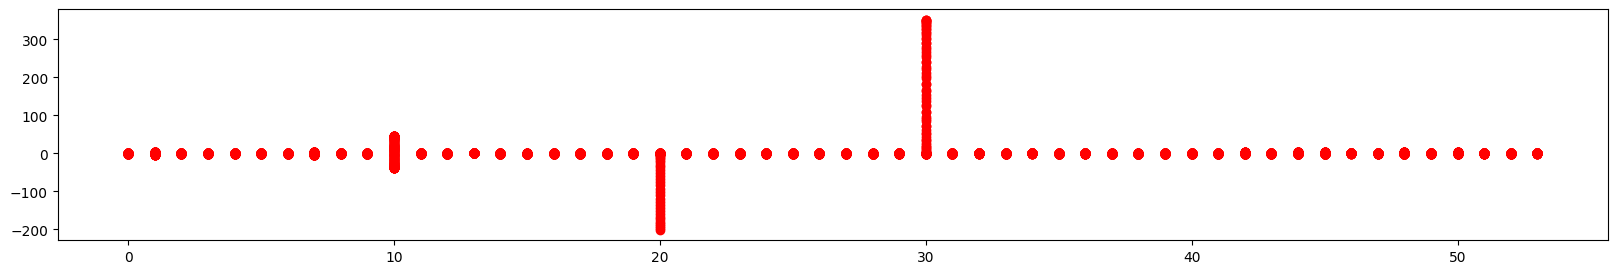

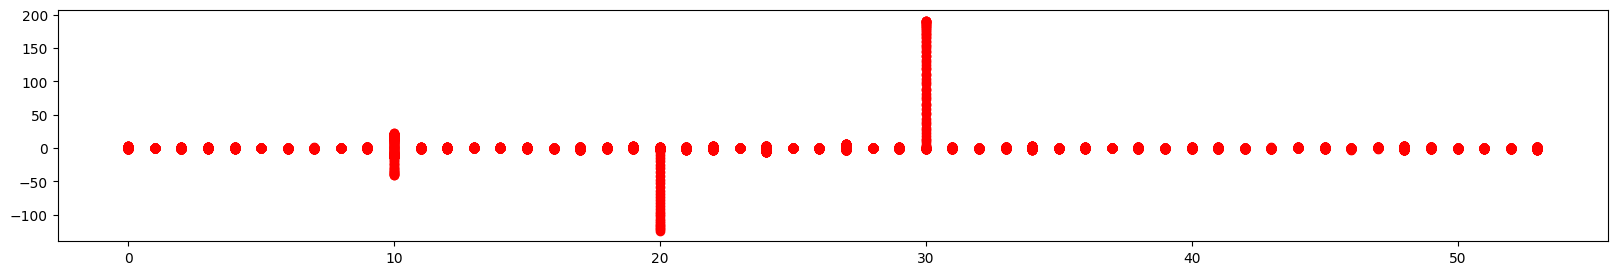

In [5]:
# Plot data grouped by signal

index = torch.ones(129, dtype=dtype, device=device)*torch.linspace(0, 54 - 1, 54, dtype=dtype, device=device).reshape(-1, 1)

plt.figure(figsize=(20, 3))
for i, value in zip(index, feature_x.reshape(54, -1)):
    plt.scatter(i.cpu().numpy(), value.cpu().numpy(), color='red')
plt.show()

plt.figure(figsize=(20, 3))
for i, value in zip(index, feature_y.reshape(54, -1)):
    plt.scatter(i.cpu().numpy(), value.cpu().numpy(), color='red')
plt.show()

# As it can be seen, signals with anomalies (10, 20 and 30) have large spread compared to other signals

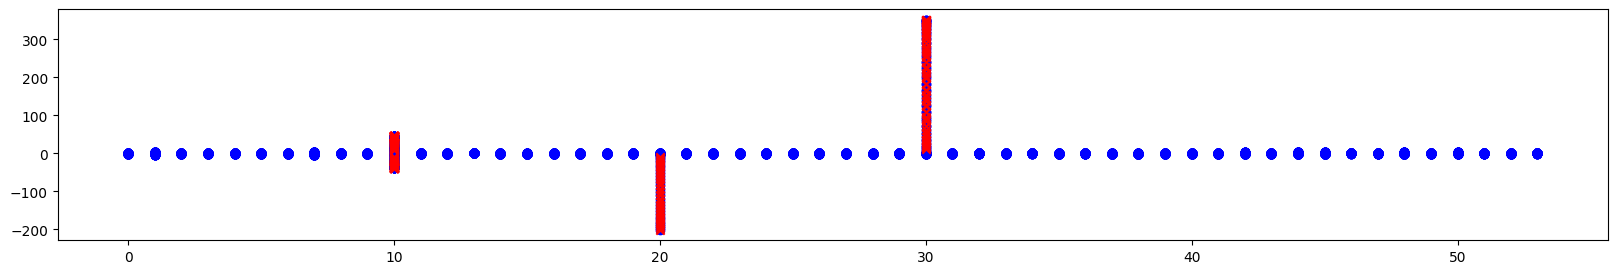

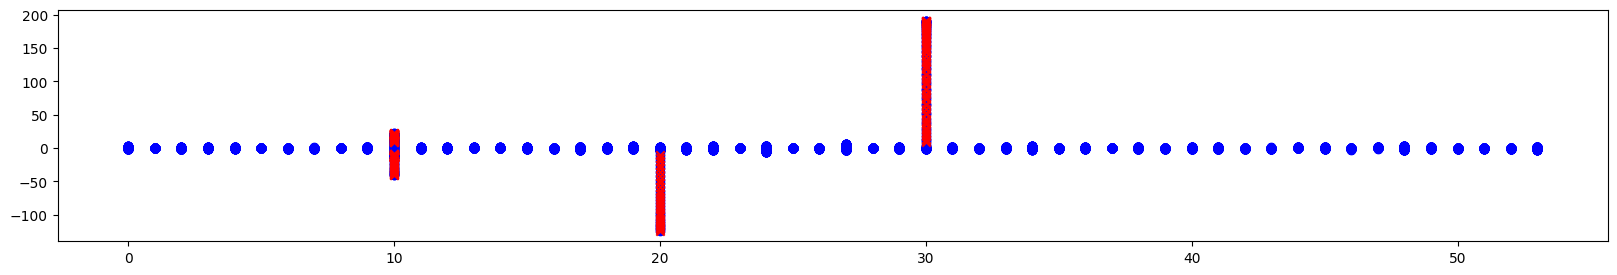

In [6]:
# Detect anomalies by threshold & plot marked samples (separately for x & y planes)

factor = 8.0

center = median(feature_x)
spread = biweight_midvariance(feature_x).sqrt()
min_value, max_value = center - factor*spread, center + factor*spread
threshold_mask_x = threshold(feature_x, min_value, max_value)

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_x.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[threshold_mask_x.reshape_as(index).logical_not()].cpu().numpy(), feature_x.reshape_as(index)[threshold_mask_x.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

center = median(feature_y)
spread = biweight_midvariance(feature_y).sqrt()
min_value, max_value = center - factor*spread, center + factor*spread
threshold_mask_y = threshold(feature_y, min_value, max_value)

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_y.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[threshold_mask_y.reshape_as(index).logical_not()].cpu().numpy(), feature_y.reshape_as(index)[threshold_mask_y.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

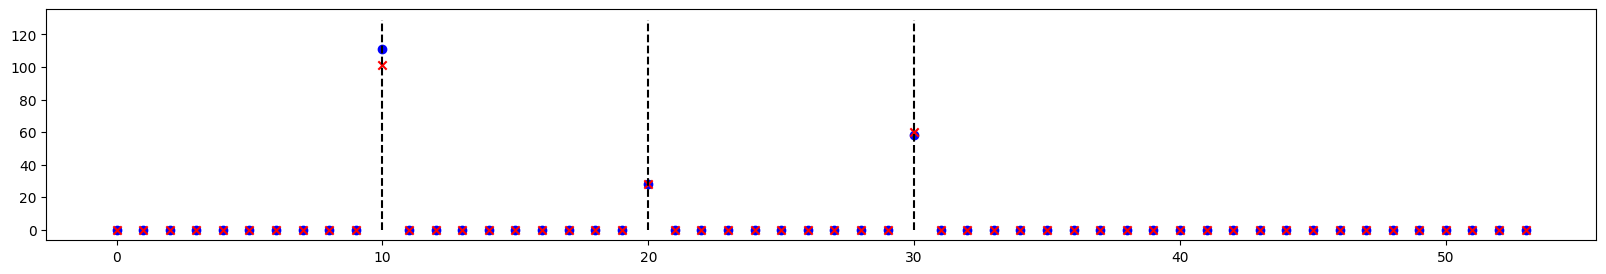

In [7]:
# Compute & plot anomaly scores (threshold)

threshold_score_x = score(54, threshold_mask_x)
threshold_score_y = score(54, threshold_mask_y)

plt.figure(figsize=(20, 3))
plt.scatter(range(54), threshold_score_x.cpu().numpy(), color='blue', marker='o')
plt.scatter(range(54), threshold_score_y.cpu().numpy(), color='red', marker='x')
plt.vlines([10, 20, 30], 0, 129, colors='black', linestyles='dashed')
plt.show()

threshold_score = threshold_score_x + threshold_score_y

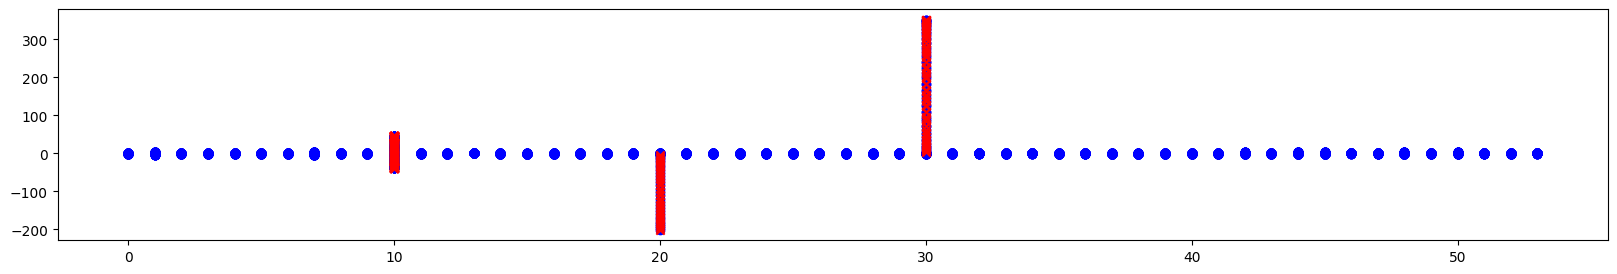

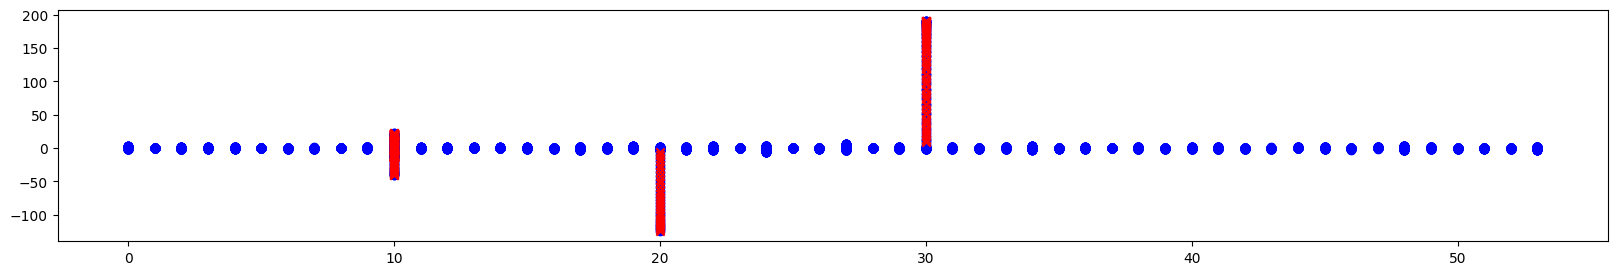

In [8]:
# Detect anomalies with DBSCAN

factor = 2.0
spread = 1.0
epsilon = factor*spread

dbscan_mask = dbscan(torch.stack([feature_x, feature_y]).T, epsilon)

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_x.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[dbscan_mask.reshape_as(index).logical_not()].cpu().numpy(), feature_x.reshape_as(index)[dbscan_mask.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_y.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[dbscan_mask.reshape_as(index).logical_not()].cpu().numpy(), feature_y.reshape_as(index)[dbscan_mask.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

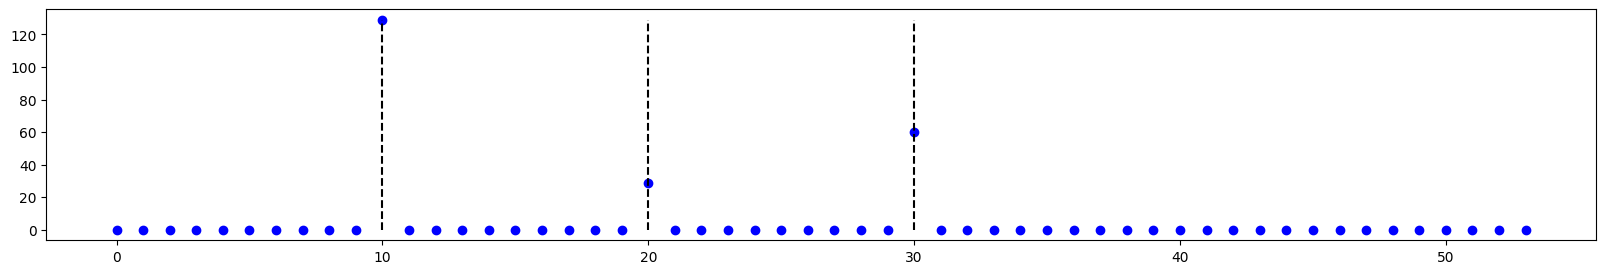

In [9]:
# Compute & plot anomaly scores (dbscan)

dbscan_score = score(54, dbscan_mask)
plt.figure(figsize=(20, 3))
plt.scatter(range(54), dbscan_score.cpu().numpy(), color='blue', marker='o')
plt.vlines([10, 20, 30], 0, 129, colors='black', linestyles='dashed')
plt.show()

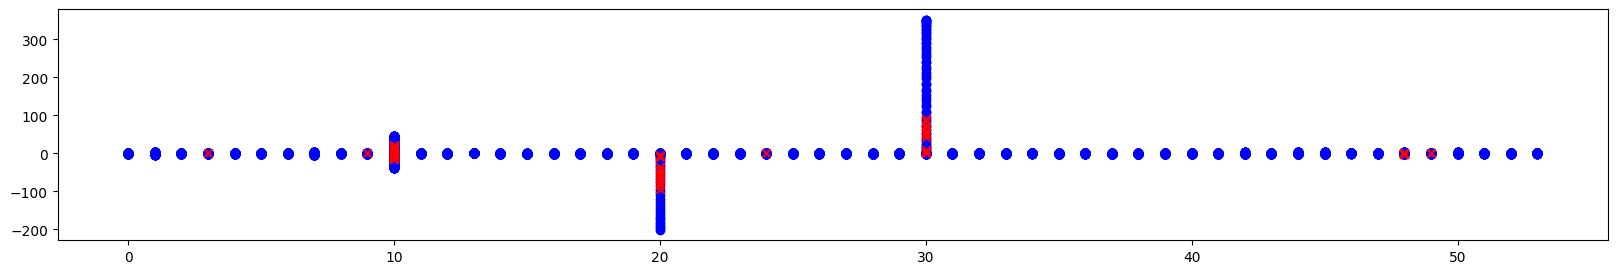

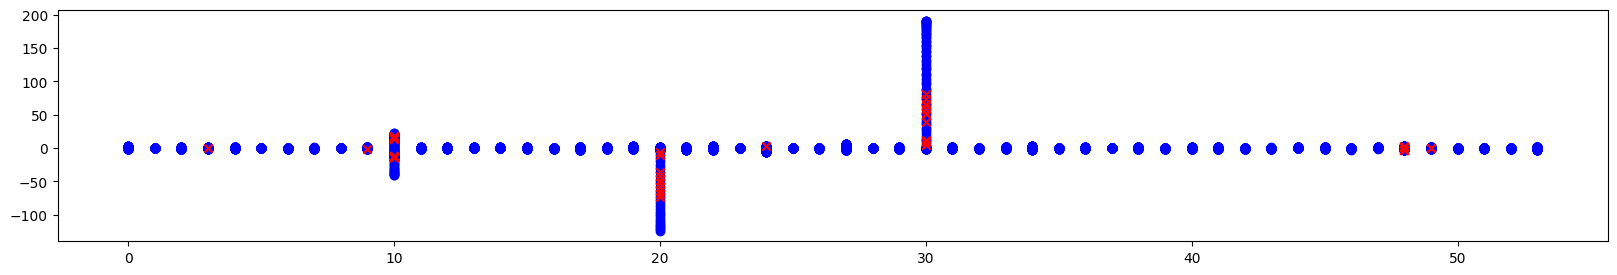

In [10]:
# Detect anomalies with local_outlier_factor

contamination = 0.01

local_outlier_factor_mask = local_outlier_factor(torch.stack([feature_x, feature_y]).T, contamination=contamination)

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_x.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[local_outlier_factor_mask.reshape_as(index).logical_not()].cpu().numpy(), feature_x.reshape_as(index)[local_outlier_factor_mask.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_y.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[local_outlier_factor_mask.reshape_as(index).logical_not()].cpu().numpy(), feature_y.reshape_as(index)[local_outlier_factor_mask.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

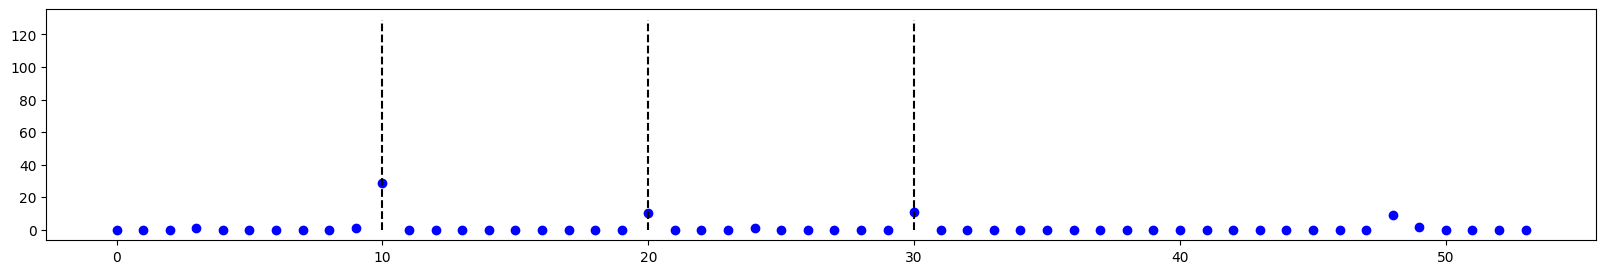

In [11]:
# Compute & plot anomaly scores (local_outlier_factor)

local_outlier_factor_score = score(54, local_outlier_factor_mask)
plt.figure(figsize=(20, 3))
plt.scatter(range(54), local_outlier_factor_score.cpu().numpy(), color='blue', marker='o')
plt.vlines([10, 20, 30], 0, 129, colors='black', linestyles='dashed')
plt.show()

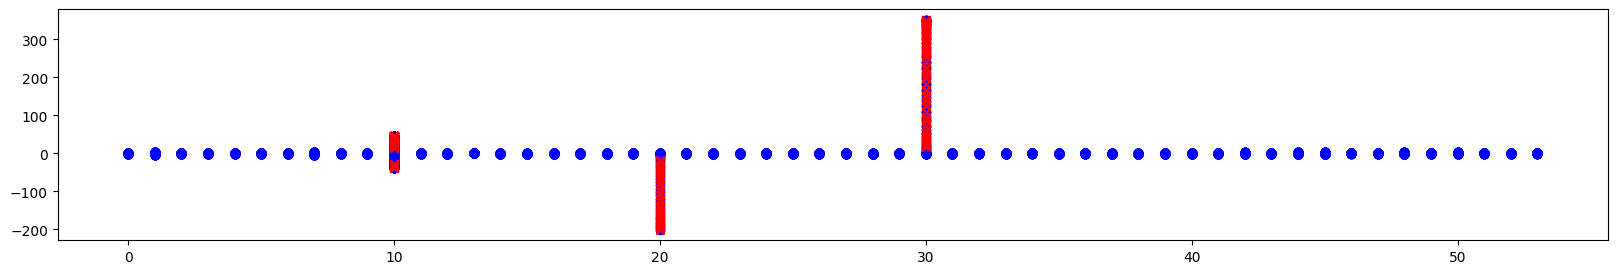

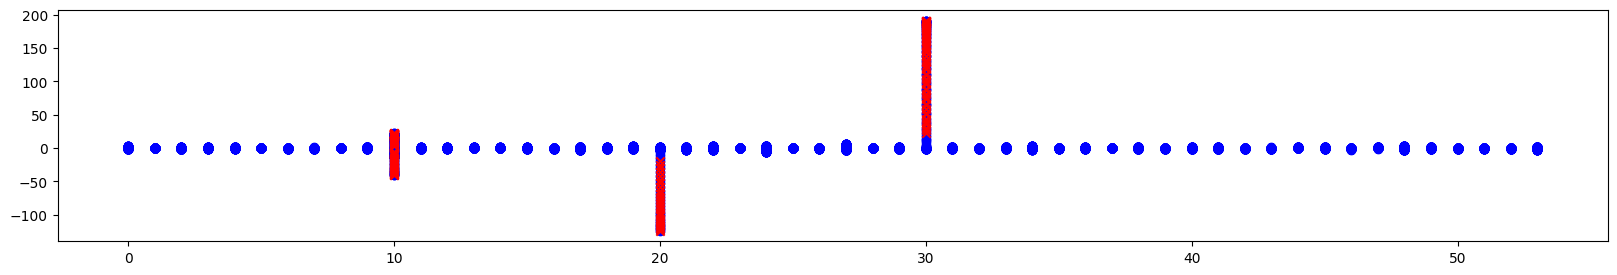

In [12]:
# Detect anomalies with isolation_forest

contamination = 0.02

isolation_forest_mask = isolation_forest(torch.stack([feature_x, feature_y]).T, contamination=contamination)

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_x.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[isolation_forest_mask.reshape_as(index).logical_not()].cpu().numpy(), feature_x.reshape_as(index)[isolation_forest_mask.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

plt.figure(figsize=(20, 3))
plt.scatter(index.cpu().numpy(), feature_y.reshape_as(index).cpu().numpy(), color='blue')
plt.scatter(index[isolation_forest_mask.reshape_as(index).logical_not()].cpu().numpy(), feature_y.reshape_as(index)[isolation_forest_mask.reshape_as(index).logical_not()].cpu().numpy(), color='red', marker='x')
plt.show()

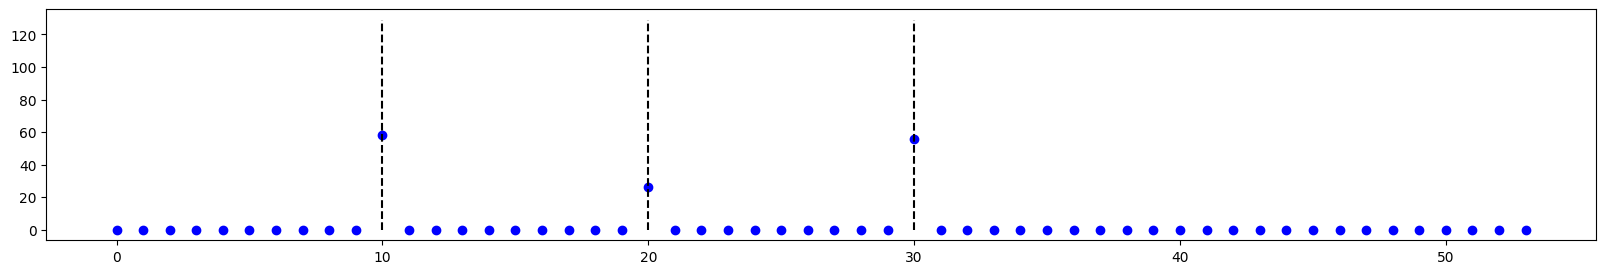

In [13]:
# Compute & plot anomaly scores (isolation_forest)

isolation_forest_score = score(54, isolation_forest_mask)
plt.figure(figsize=(20, 3))
plt.scatter(range(54), isolation_forest_score.cpu().numpy(), color='blue', marker='o')
plt.vlines([10, 20, 30], 0, 129, colors='black', linestyles='dashed')
plt.show()

In [14]:
# Note, both Local Outlier Factor and Isolation Forest can produce rather large number of false positives
# This is the case for large contamination factor

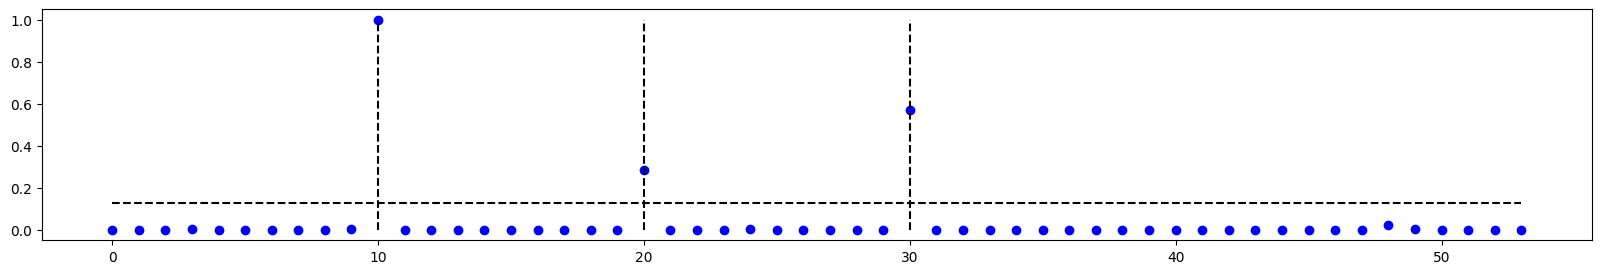

In [15]:
# Combine & threshold scores

total = (threshold_score + dbscan_score + local_outlier_factor_score + isolation_forest_score).to(torch.float64)
total = rescale(total, scale_min=0.0, scale_max=1.0)

limit = 5.0*variance(total) 
clear = total < limit

plt.figure(figsize=(20, 3))
plt.scatter(range(54), total.cpu().numpy(), color='blue', marker='o')
plt.vlines([10, 20, 30], 0, 1, colors='black', linestyles='dashed')
plt.hlines(limit.cpu().numpy(), 0, 53, colors='black', linestyles='dashed')
plt.show()

In [16]:
# Estimate frequency with removed anomaly signals (all samples are removed)

# + anomalies

print('+ anomalies')
print(f'nux: {mean(data_x.flatten()).cpu().item():12.9}, {variance(data_x.flatten()).sqrt().cpu().item():12.9}')
print(f'nuy: {mean(data_y.flatten()).cpu().item():12.9}, {variance(data_y.flatten()).sqrt().cpu().item():12.9}')
print(f'error_x: {abs(nux - mean(data_x.flatten()).cpu().item()):12.9}')
print(f'error_y: {abs(nuy - mean(data_y.flatten()).cpu().item()):12.9}')
print()

# - anomalies

print('- anomalies')
print(f'nux: {mean(data_x[clear].flatten()).cpu().item():12.9}, {variance(data_x[clear].flatten()).sqrt().cpu().item():12.9}')
print(f'nuy: {mean(data_y[clear].flatten()).cpu().item():12.9}, {variance(data_y[clear].flatten()).sqrt().cpu().item():12.9}')
print(f'error_x: {abs(nux - mean(data_x[clear].flatten()).cpu().item()):12.9}')
print(f'error_y: {abs(nuy - mean(data_y[clear].flatten()).cpu().item()):12.9}')
print()

# In general, with removed anomalies, both center and spread estimation are improved

+ anomalies
nux:  0.463120291, 5.68058472e-05
nuy:   0.42322746, 3.66763883e-05
error_x: 3.38934788e-06
error_y: 2.09340416e-06

- anomalies
nux:  0.463116925, 2.68466735e-06
nuy:  0.423225563, 2.94683536e-06
error_x: 2.33626125e-08
error_y: 1.95932718e-07



In [17]:
# Slightly better results might be obtained if only marked samples are removed (even better, if weights are avalible)
# Note, here x & y planes are used together, note, 'good' samples can be exluded based on the other plane

# Remove flagged samples only from marked signals

mask_x = threshold_mask_x*threshold_mask_y*dbscan_mask*local_outlier_factor_mask*isolation_forest_mask
mask_x = mask_x.reshape(54, -1)
mask_x[clear] = True

mask_y = threshold_mask_x*threshold_mask_y*dbscan_mask*local_outlier_factor_mask*isolation_forest_mask
mask_y = mask_y.reshape(54, -1)
mask_y[clear] = True

print(f'nux: {mean(data_x[mask_x].flatten()).cpu().item():12.9}, {variance(data_x[mask_x].flatten()).sqrt().cpu().item():12.9}')
print(f'nuy: {mean(data_y[mask_y].flatten()).cpu().item():12.9}, {variance(data_y[mask_y].flatten()).sqrt().cpu().item():12.9}')
print(f'error_x: {abs(nux - mean(data_x[mask_x].flatten()).cpu().item()):12.9}')
print(f'error_y: {abs(nuy - mean(data_y[mask_y].flatten()).cpu().item()):12.9}')
print()

nux:  0.463116916, 2.66064306e-06
nuy:  0.423225524, 2.96095207e-06
error_x: 1.43348142e-08
error_y: 1.57007253e-07

